Chargement et première exploration des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('marketing_campaign.csv', sep=';') 
print("Forme du dataset :", df.shape)
print(df.head())
print(df.info())

Forme du dataset : (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp

- 2240 clients et 29 colonnes – taille modérée, idéale pour une exploration rapide.

- Pas de problème de séparation : le fichier est correctement lu avec le séparateur ;.

- Valeurs manquantes : seule la colonne Income a 24 valeurs manquantes (sur 2240). Il faudra les traiter (imputation par médiane, par exemple).

- Colonnes constantes : Z_CostContact (valeur 3 partout) et Z_Revenue (valeur 11 partout) n’apportent aucune information ; elles peuvent être ignorées dans l’analyse.

- Types : variables numériques (int, float) et catégorielles (Education, Marital_Status, et Dt_Customer à convertir en date).

- Cible Response : variable binaire à analyser (taux de réponse probablement faible, comme dans les campagnes marketing classiques).

Nettoyage et préparation des données

Gestion des valeurs manquantes

In [3]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

# Par exemple, Income peut avoir des NaN
print(df['Income'].describe())
# Remplacer les NaN par la médiane (ou autre méthode)
df['Income'].fillna(df['Income'].median(), inplace=True)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


- Valeurs manquantes : seules 24 lignes (sur 2240) ont un revenu manquant. L’imputation par la médiane (51 381,5 €) est une méthode robuste car la distribution du revenu est asymétrique (max très élevé à 666 666 €).

- Distribution du revenu :

    - Moyenne : 52 247 € (tirée vers le haut par les valeurs extrêmes).

    - Médiane : 51 381 € → bonne indication du revenu typique.

    - Écart‑type élevé (25 173 €) et max à 666 666 € suggèrent des outliers qui pourront être traités ou conservés selon le modèle.

Conversion des types

In [4]:
# Convertir la date d'inscription
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
# Créer une colonne "Ancienneté" (nombre de jours depuis l'inscription)
df['Customer_Age_days'] = (pd.Timestamp.now() - df['Dt_Customer']).dt.days

Encodage des variables catégorielles

In [5]:
# Afficher les modalités
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())

# On pourra les encoder plus tard pour les modèles, mais pour l'EDA, on les garde en l'état.
# On peut toutefois regrouper certaines catégories (ex: 'Marital_Status').

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Création d’une variable de dépense totale

In [6]:
# Colonnes de dépenses
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

Analyse univariée

Distribution de la variable cible Response

Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


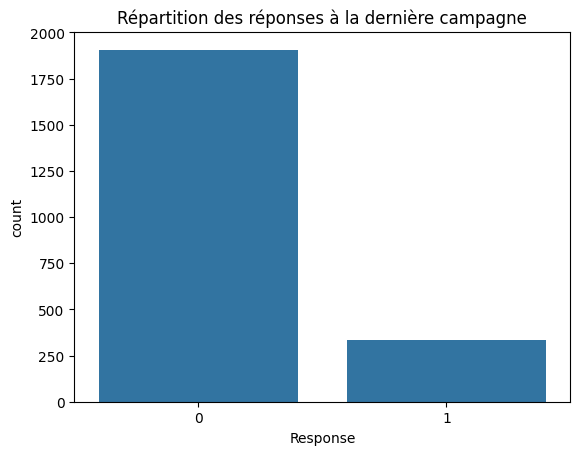

In [7]:
print(df['Response'].value_counts(normalize=True))
sns.countplot(x='Response', data=df)
plt.title('Répartition des réponses à la dernière campagne')
plt.show()

Analyse des dépenses

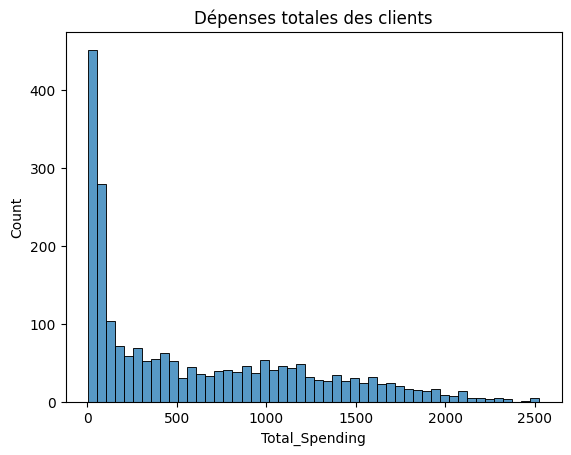

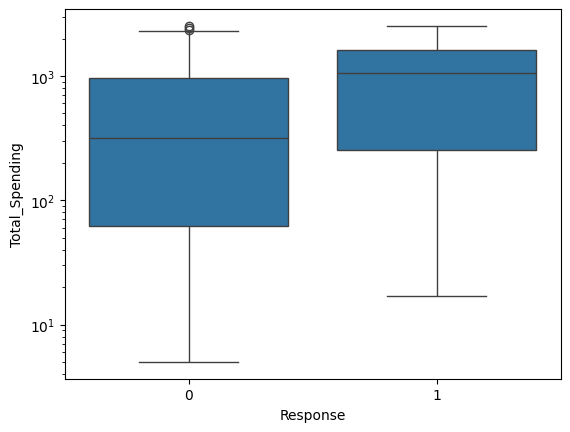

In [8]:
# Distribution des dépenses totales
sns.histplot(df['Total_Spending'], bins=50)
plt.title('Dépenses totales des clients')
plt.show()

# Boxplot des dépenses par réponse
sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.yscale('log')
plt.show()

Analyse des comportements d’achat

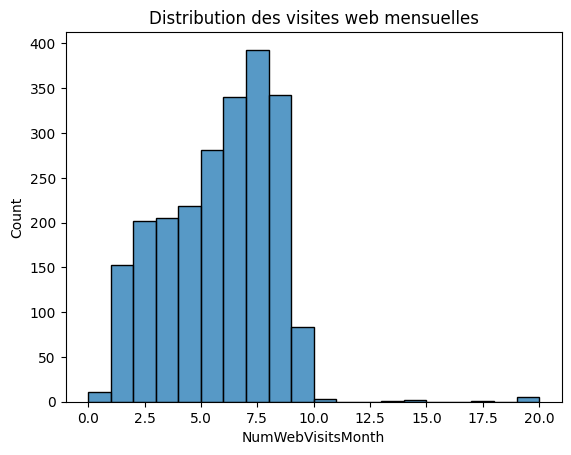

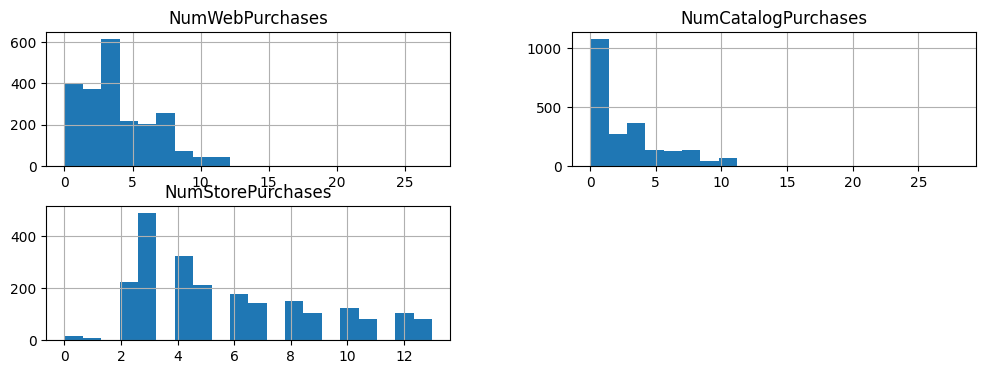

In [9]:
# Nombre de visites web
sns.histplot(df['NumWebVisitsMonth'], bins=20)
plt.title('Distribution des visites web mensuelles')
plt.show()

# Nombre d’achats par canal
channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df[channels].hist(bins=20, figsize=(12,4))
plt.show()

Analyse multivariée

Corrélations entre variables numériques

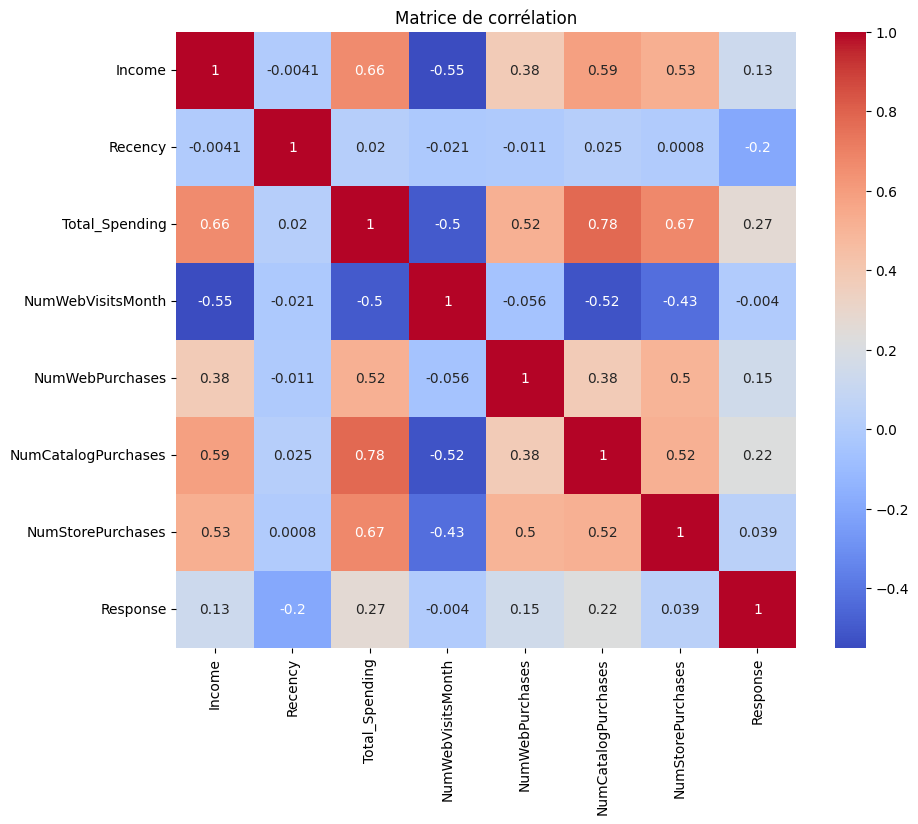

In [10]:
# Sélectionner les colonnes numériques pertinentes
num_cols = ['Income', 'Recency', 'Total_Spending', 'NumWebVisitsMonth',
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
            'Response']
corr = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

Comparaison des profils selon la réponse

In [11]:
# Profil moyen des clients ayant répondu vs non
response_group = df.groupby('Response')[num_cols].mean()
print(response_group)

                Income    Recency  Total_Spending  NumWebVisitsMonth  \
Response                                                               
0         50845.677597  51.514690      538.929171           5.320567   
1         60183.244012  35.383234      987.392216           5.293413   

          NumWebPurchases  NumCatalogPurchases  NumStorePurchases  Response  
Response                                                                     
0                3.911857             2.391920           5.736621       0.0  
1                5.071856             4.203593           6.095808       1.0  


Différences entre répondants et non-répondants
Les répondants (classe 1) présentent un profil plus engagé que les non-répondants (classe 0) :

- Revenu : 60 183 € en moyenne contre 50 846 € (+18 %).

- Dépenses totales : 987 € contre 539 € (+83 %).

- Récence : dernier achat il y a 35 jours contre 51 jours (plus récents).

- Achats web : 5,1 contre 3,9 par an.

- Achats catalogue : 4,2 contre 2,4 par an.

- Achats magasin : 6,1 contre 5,7 par an (différence modérée).

- Visites web mensuelles : identiques (~5,3).

Ces écarts montrent que les répondants sont des clients plus actifs, plus dépensiers, plus récents et utilisant davantage les canaux web et catalogue. Ces variables seront particulièrement utiles pour la modélisation prédictive.

Relation entre revenu et dépenses

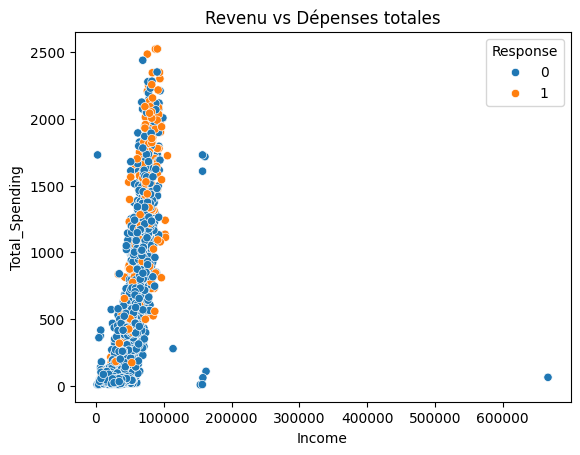

In [12]:
sns.scatterplot(x='Income', y='Total_Spending', hue='Response', data=df)
plt.title('Revenu vs Dépenses totales')
plt.show()

Analyse par catégories

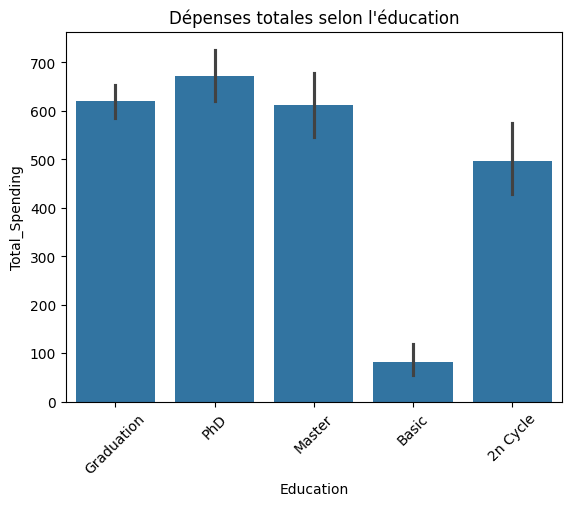

In [13]:
# Dépenses moyennes par niveau d'éducation
sns.barplot(x='Education', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title('Dépenses totales selon l\'éducation')
plt.show()

Segmentation des clients

Utilisation de variables clés pour segmenter

In [14]:
# Définir des groupes
df['Income_Group'] = pd.qcut(df['Income'], q=4, labels=['Faible', 'Moyen', 'Élevé', 'Très élevé'])
df['Spending_Group'] = pd.qcut(df['Total_Spending'], q=4, labels=['Faible', 'Moyen', 'Élevé', 'Très élevé'])

# Analyser le taux de réponse par segment
segment_response = df.groupby(['Income_Group', 'Spending_Group'])['Response'].mean().unstack()
print(segment_response)

Spending_Group    Faible     Moyen     Élevé  Très élevé
Income_Group                                            
Faible          0.067935  0.173184  0.166667    0.000000
Moyen           0.034682  0.130435  0.214286    0.363636
Élevé           0.000000  0.020408  0.082508    0.227273
Très élevé      0.000000  0.000000  0.113636    0.322115


C:\Users\danis\AppData\Local\Temp\ipykernel_16160\2354707341.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_response = df.groupby(['Income_Group', 'Spending_Group'])['Response'].mean().unstack()


- Le taux de réponse est faible chez les clients à la fois à faible revenu et à faibles dépenses (6,8 %).

- Les meilleurs taux de réponse se trouvent dans les segments « Moyen revenu – Dépenses très élevées » (36,4 %) et « Très haut revenu – Dépenses très élevées » (32,2 %).

- Un revenu élevé seul ne garantit pas une bonne réponse : il faut également des dépenses importantes.

- Les clients à dépenses très élevées sont systématiquement plus réactifs, quel que soit leur revenu.

Ces résultats montrent que le croisement revenu × dépenses est un excellent indicateur pour cibler les campagnes marketing.

Visualisation des segments rentables

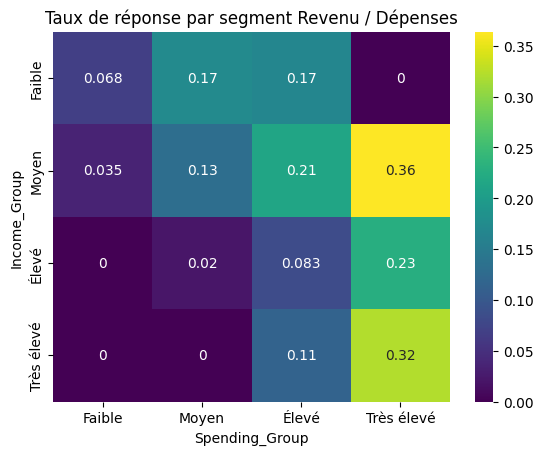

In [15]:
sns.heatmap(segment_response, annot=True, cmap='viridis')
plt.title('Taux de réponse par segment Revenu / Dépenses')
plt.show()

Analyse du comportement d’achat par canal

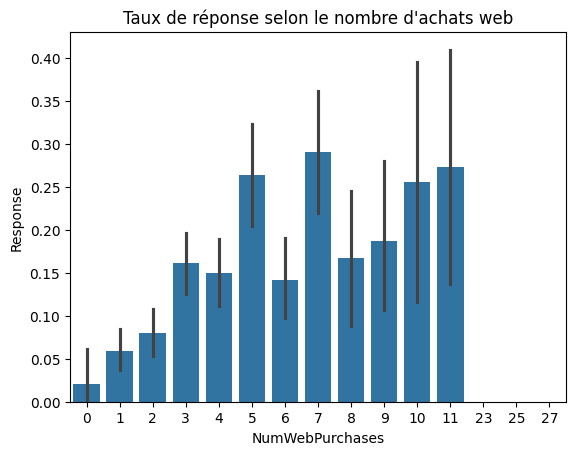

In [16]:
# Taux de réponse selon le nombre d’achats web
sns.barplot(x='NumWebPurchases', y='Response', data=df)
plt.title('Taux de réponse selon le nombre d\'achats web')
plt.show()

7. Formulation d’hypothèses exploitables

- Dépenses et récence : les répondants dépensent davantage (+83 %) et sont plus récents (35 vs 51 jours) → prioriser ces variables dans la modélisation.

- Multi‑canaux : les achats web et catalogue sont plus fréquents chez les répondants → créer un score d’omnichannel.

- Historique des campagnes : le nombre d’acceptations passées est fortement prédictif → l’inclure comme variable.

- Segmentation revenu × dépenses : les meilleurs taux de réponse (36 %) se trouvent dans le segment « revenu moyen – dépenses très élevées » → utiliser ce croisement pour le ciblage.